In [1]:
# ========================================
# 1. 설정 (Configuration)
# ========================================

PRJ_PATH = "/home/work/mlp/hslim/LASEF2"

TRANSLATED = False
ROLLOUT = True
ROLLOUT_COUNT = 5
MODEL = "Qwen2.5-7B-Instruct"
DATASET = "mgsm-all-low-resource-translated" # Example
DATA_DIR = f"{PRJ_PATH}/data/results/SkelLang/{DATASET}"
FASTTEXT_MODEL_PATH = f"{PRJ_PATH}/lid.176.bin"

SKELETON_LANGUAGES = ["zh", "es", "ru", "ko", "th"]

COT_LANGUAGES = [
    "ta", "kn", "my", "km", "am", "yo", "si", "gu", "ne", "uz", "ky", "ceb", 
    "eu", "gn", "hy", "jv", "ka", "kk", "ku", "lo", "mg", "ml", "mn", "mr", 
    "mt", "or", "pa", "ps", "qu", "sd", "so", "su", "tg", "ug"
]

LANGUAGE_NAMES = {
    "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
    "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
    "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
    "uz": "Uzbek", "ky": "Kyrgyz",
    "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
    "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
    "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
    "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
    "mr": "Marathi", "mt": "Maltese", "or": "Odia",
    "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
    "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
    "tg": "Tajik", "ug": "Uyghur",
    "en": "English", "zh": "Chinese", "es": "Spanish",
    "ko": "Korean", "th": "Thai", "sw": "Swahili", "te": "Telugu",
}

print(f"Model: {MODEL}")
print(f"Skeleton Languages: {SKELETON_LANGUAGES}")
print(f"CoT Languages: {COT_LANGUAGES}")

Model: Qwen2.5-7B-Instruct
Skeleton Languages: ['zh', 'es', 'ru', 'ko', 'th']
CoT Languages: ['ta', 'kn', 'my', 'km', 'am', 'yo', 'si', 'gu', 'ne', 'uz', 'ky', 'ceb', 'eu', 'gn', 'hy', 'jv', 'ka', 'kk', 'ku', 'lo', 'mg', 'ml', 'mn', 'mr', 'mt', 'or', 'pa', 'ps', 'qu', 'sd', 'so', 'su', 'tg', 'ug']


In [2]:
# ========================================
# 2. Imports & Helper Functions
# ========================================
import fasttext
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
from scipy.stats import wilcoxon
from math_verify import parse, verify

fasttext.FastText.eprint = lambda x: None
lang_model = fasttext.load_model(FASTTEXT_MODEL_PATH)
print("FastText model loaded successfully")

def calculate_wilcoxon_pvalue(scores_a, scores_b):
    diffs = [b - a for a, b in zip(scores_a, scores_b)]
    if all(d == 0 for d in diffs):
        return 1.0
    try:
        res = wilcoxon(scores_a, scores_b, zero_method='wilcox')
        return res.pvalue
    except ValueError:
        return 1.0

def detect_language(text):
    global lang_model
    if text is None or not isinstance(text, str):
        return "unk"
    text = text.replace("\n", " ").strip()
    if len(text) < 2:
        return "unk"
    try:
        labels, probs = lang_model.predict(text, k=1)
        if not probs or len(probs) == 0:
            return "unk"
        return labels[0].replace("__label__", "")
    except:
        return "unk"

def load_jsonl(filepath):
    data = []
    if not os.path.exists(filepath):
        print(f"⚠️ File not found: {filepath}")
        return None
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except:
                pass
    return data

def add_detected_languages(data, detect_skeleton=False):
    for item in tqdm(data, desc="Detecting languages", leave=False):
        responses = item.get('responses', [])[:5]
        item['detected_response_languages'] = [detect_language(r if isinstance(r, str) else "") for r in responses]
        
        item['detected_response_language'] = item['detected_response_languages'][0] if item['detected_response_languages'] else "unk"
        
        if detect_skeleton:
            skeleton = item.get('skeleton', [])
            skel_text = skeleton[0] if isinstance(skeleton, list) and len(skeleton) > 0 else (skeleton if isinstance(skeleton, str) else "")
            item['detected_skeleton_language'] = detect_language(skel_text)
    return data

def group_by_language(data):
    grouped = defaultdict(list)
    for item in data:
        lang = item.get('question_language', 'unknown')
        grouped[lang].append(item)
    return grouped

def evaluate_all_metrics(args):
    example_a, example_b, cot_lang = args
    responses_a = example_a.get('responses', [])[:5]
    responses_b = example_b.get('responses', [])[:5]
    langs_a = example_a.get('detected_response_languages', [])[:5]
    langs_b = example_b.get('detected_response_languages', [])[:5]
    
    try:
        gold = parse(str(example_a['answer']))
        
        def get_metrics(responses, langs):
            if not responses: return 0.0, 0.0, 0.0
            
            scores_strict = []
            scores_pure = []
            compliances = []
            
            for r, l in zip(responses, langs):
                is_comp = (l == cot_lang)
                compliances.append(1.0 if is_comp else 0.0)
                
                try:
                    pred = parse(str(r))
                    is_correct = int(verify(gold, pred))
                except:
                    is_correct = 0
                    
                if is_comp:
                    scores_strict.append(is_correct)
                    scores_pure.append(is_correct)
                else:
                    scores_strict.append(0) # Option A: mismatch = 0
                    
            avg_strict = sum(scores_strict) / len(scores_strict)
            avg_pure = sum(scores_pure) / len(scores_pure) if scores_pure else np.nan
            avg_comp = sum(compliances) / len(compliances)
            
            return avg_strict, avg_pure, avg_comp

        strict_a, pure_a, comp_a = get_metrics(responses_a, langs_a)
        strict_b, pure_b, comp_b = get_metrics(responses_b, langs_b)
        
        return strict_a, strict_b, pure_a, pure_b, comp_a, comp_b, 0
    except:
        return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1

def get_baseline_path(tr, ro, roc):
    if tr:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en-Google-transQ{'_rollout'+str(roc) if ro else ''}.jsonl")
    else:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en{'_rollout'+str(roc) if ro else ''}.jsonl")
    return path

def get_skellang_path(skel_lang, tr, ro, roc):
    if tr:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}-Google-transQ{'_rollout'+str(roc) if ro else ''}.jsonl")
    else:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}{'_rollout'+str(roc) if ro else ''}.jsonl")
    return path

FastText model loaded successfully


## 데이터 로딩 및 3가지 지표 통합 평가 (Evaluation Loop)
이 루프에서는 한 번의 평가로 다음 세 가지 지표를 모두 계산합니다:
1. **Strict Accuracy (Option A)**: Language Mismatch를 0점 처리한 정확도
2. **Pure Reasoning Accuracy (Option B)**: 타겟 언어로 답변한 Rollout들 안에서의 평균 정확도
3. **Language Compliance Rate**: 5개의 Rollout 중 타겟 언어로 제대로 답변한 비율

In [3]:
# ========================================
# 3. 데이터 로드 및 3종 메트릭 평가
# ========================================

print("📂 Loading baseline data (English skeleton)...")
baseline_path = get_baseline_path(TRANSLATED, ROLLOUT, ROLLOUT_COUNT)
baseline_data = load_jsonl(baseline_path)

if baseline_data:
    baseline_data = add_detected_languages(baseline_data, detect_skeleton=False)
    baseline_grouped = group_by_language(baseline_data)
else:
    print("❌ Baseline file not found!")

# 결과 저장용 매트릭스
matrix_strict = defaultdict(dict)
matrix_pure = defaultdict(dict)
matrix_comp = defaultdict(dict)
pvalue_strict = defaultdict(dict)
pvalue_pure = defaultdict(dict)
pvalue_comp = defaultdict(dict)

for skel_lang in SKELETON_LANGUAGES:
    print(f"\n{'─'*60}")
    print(f"📊 Skeleton Language: {skel_lang.upper()}")
    print(f"{'─'*60}")
    
    target_path = get_skellang_path(skel_lang, TRANSLATED, ROLLOUT, ROLLOUT_COUNT)
    target_data = load_jsonl(target_path)
    if target_data is None:
        continue
    target_data = add_detected_languages(target_data, detect_skeleton=True)
    target_grouped = group_by_language(target_data)
    
    for cot_lang in COT_LANGUAGES:
        baseline_lang_data = baseline_grouped.get(cot_lang, [])
        target_lang_data = target_grouped.get(cot_lang, [])
        
        if not baseline_lang_data or not target_lang_data:
            continue
            
        min_len = min(len(baseline_lang_data), len(target_lang_data))
        baseline_lang_data = baseline_lang_data[:min_len]
        target_lang_data = target_lang_data[:min_len]
        
        filtered_pairs = []
        for item_a, item_b in zip(baseline_lang_data, target_lang_data):
            # Pair Filtering: 둘 다 최소 1개의 compliant rollout이 있어야 함
            langs_a = item_a.get('detected_response_languages', [])
            langs_b = item_b.get('detected_response_languages', [])
            if cot_lang not in langs_a or cot_lang not in langs_b:
                continue
            
            # Skeleton language mismatched filter (optional, keeping it from original code)
            detected_skel = item_b.get('detected_skeleton_language', 'unk')
            if detected_skel != skel_lang:
                continue
                
            filtered_pairs.append((item_a, item_b))
            
        if len(filtered_pairs) < 10:
            continue
            
        with Pool(cpu_count()) as pool:
            eval_args = [(a, b, cot_lang) for a, b in filtered_pairs]
            results = list(tqdm(pool.imap(evaluate_all_metrics, eval_args), total=len(eval_args), desc=f"   Eval {cot_lang}", leave=False))
            
        valid_results = [r for r in results if r[6] == 0]
        total = len(valid_results)
        if total == 0:
            continue
            
        # Unpack metrics
        strict_a = [r[0] for r in valid_results]
        strict_b = [r[1] for r in valid_results]
        pure_a = [r[2] for r in valid_results]
        pure_b = [r[3] for r in valid_results]
        comp_a = [r[4] for r in valid_results]
        comp_b = [r[5] for r in valid_results]
        
        # 1. Strict Accuracy (Option A)
        avg_strict_a = sum(strict_a) / total * 100
        avg_strict_b = sum(strict_b) / total * 100
        matrix_strict[skel_lang][cot_lang] = avg_strict_b - avg_strict_a
        pvalue_strict[skel_lang][cot_lang] = calculate_wilcoxon_pvalue(strict_a, strict_b)
        
        # 2. Pure Reasoning Accuracy (Option B)
        avg_pure_a = sum(pure_a) / total * 100
        avg_pure_b = sum(pure_b) / total * 100
        matrix_pure[skel_lang][cot_lang] = avg_pure_b - avg_pure_a
        pvalue_pure[skel_lang][cot_lang] = calculate_wilcoxon_pvalue(pure_a, pure_b)
        
        # 3. Compliance Rate
        avg_comp_a = sum(comp_a) / total * 100
        avg_comp_b = sum(comp_b) / total * 100
        matrix_comp[skel_lang][cot_lang] = avg_comp_b - avg_comp_a
        pvalue_comp[skel_lang][cot_lang] = calculate_wilcoxon_pvalue(comp_a, comp_b)
        
        print(f"   [{cot_lang}] Valid: {total} | Strict Δ: {avg_strict_b - avg_strict_a:+.1f}% | Pure Δ: {avg_pure_b - avg_pure_a:+.1f}% | Comp Δ: {avg_comp_b - avg_comp_a:+.1f}%")

📂 Loading baseline data (English skeleton)...



────────────────────────────────────────────────────────────
📊 Skeleton Language: ZH
────────────────────────────────────────────────────────────


   [ta] Valid: 250 | Strict Δ: +1.4% | Pure Δ: +1.5% | Comp Δ: -0.2%


   [kn] Valid: 250 | Strict Δ: -2.6% | Pure Δ: -2.7% | Comp Δ: +0.1%


   [my] Valid: 250 | Strict Δ: -1.1% | Pure Δ: -1.0% | Comp Δ: -0.1%


...

   [sd] Valid: 245 | Strict Δ: +2.0% | Pure Δ: +1.9% | Comp Δ: +1.4%


   [so] Valid: 156 | Strict Δ: -1.7% | Pure Δ: -4.3% | Comp Δ: -0.4%


   [su] Valid: 209 | Strict Δ: +1.4% | Pure Δ: -1.4% | Comp Δ: +7.7%


   [tg] Valid: 247 | Strict Δ: -3.5% | Pure Δ: -4.5% | Comp Δ: -1.7%


   [ug] Valid: 248 | Strict Δ: -4.0% | Pure Δ: -4.1% | Comp Δ: +0.2%


## 히트맵 1. Option A: Strict Accuracy (Language Mismatch = 0점)
**의미:** 타겟 언어로 답변하지 않은 Rollout을 오답 처리한 보수적인 평가입니다. 언어 준수율과 추론 정확도가 모두 결합된 종합적 성능을 보여줍니다.

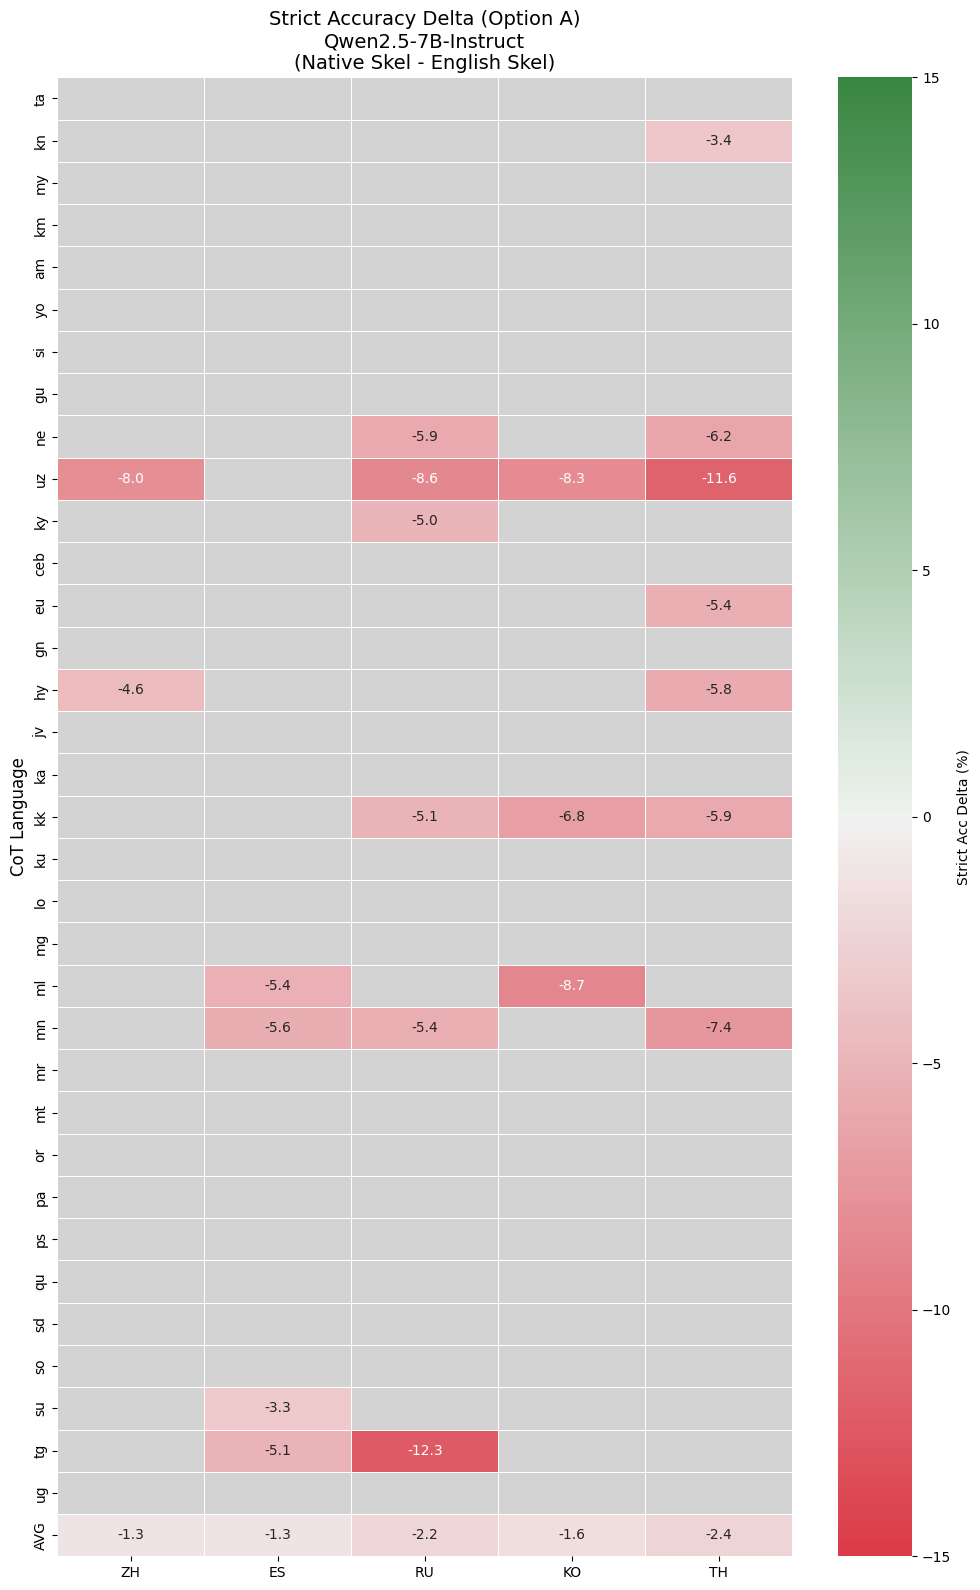

In [4]:
df_strict = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_strict_p = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel in SKELETON_LANGUAGES:
    for cot in COT_LANGUAGES:
        if skel in matrix_strict and cot in matrix_strict[skel]:
            df_strict.loc[cot, skel] = matrix_strict[skel][cot]
            df_strict_p.loc[cot, skel] = pvalue_strict[skel][cot]
        else:
            df_strict.loc[cot, skel] = np.nan
            df_strict_p.loc[cot, skel] = np.nan

df_strict.loc["AVG"] = df_strict.mean(axis=0, skipna=True)
df_strict_p.loc["AVG"] = 0.0 # To show in heatmap

x_labels = [f"{lang.upper()}" for lang in SKELETON_LANGUAGES]
y_labels = [*COT_LANGUAGES, "AVG"]

plt.figure(figsize=(10, 16))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df_strict.astype(float),
    mask=(df_strict_p >= 0.05), # p-value 0.05 이상은 회색 처리
    annot=True, fmt=".1f", cmap=cmap, center=0, vmin=-15, vmax=15, linewidths=0.5,
    xticklabels=x_labels, yticklabels=y_labels, cbar_kws={'label': 'Strict Acc Delta (%)'}
)
ax.set_facecolor('lightgrey')
plt.title(f"Strict Accuracy Delta (Option A)\n{MODEL}\n(Native Skel - English Skel)", fontsize=14)
plt.ylabel("CoT Language", fontsize=12)
plt.tight_layout()
plt.show()

## 히트맵 2. Option B: Pure Reasoning Accuracy
**의미:** 5개 Rollout 중 타겟 언어로 올바르게 대답한 Rollout들 내부에서의 정답률만 비교합니다. 모델이 타겟 언어의 '추론(Reasoning)' 능력을 순수하게 얼마나 향상시켰는지 보여줍니다.

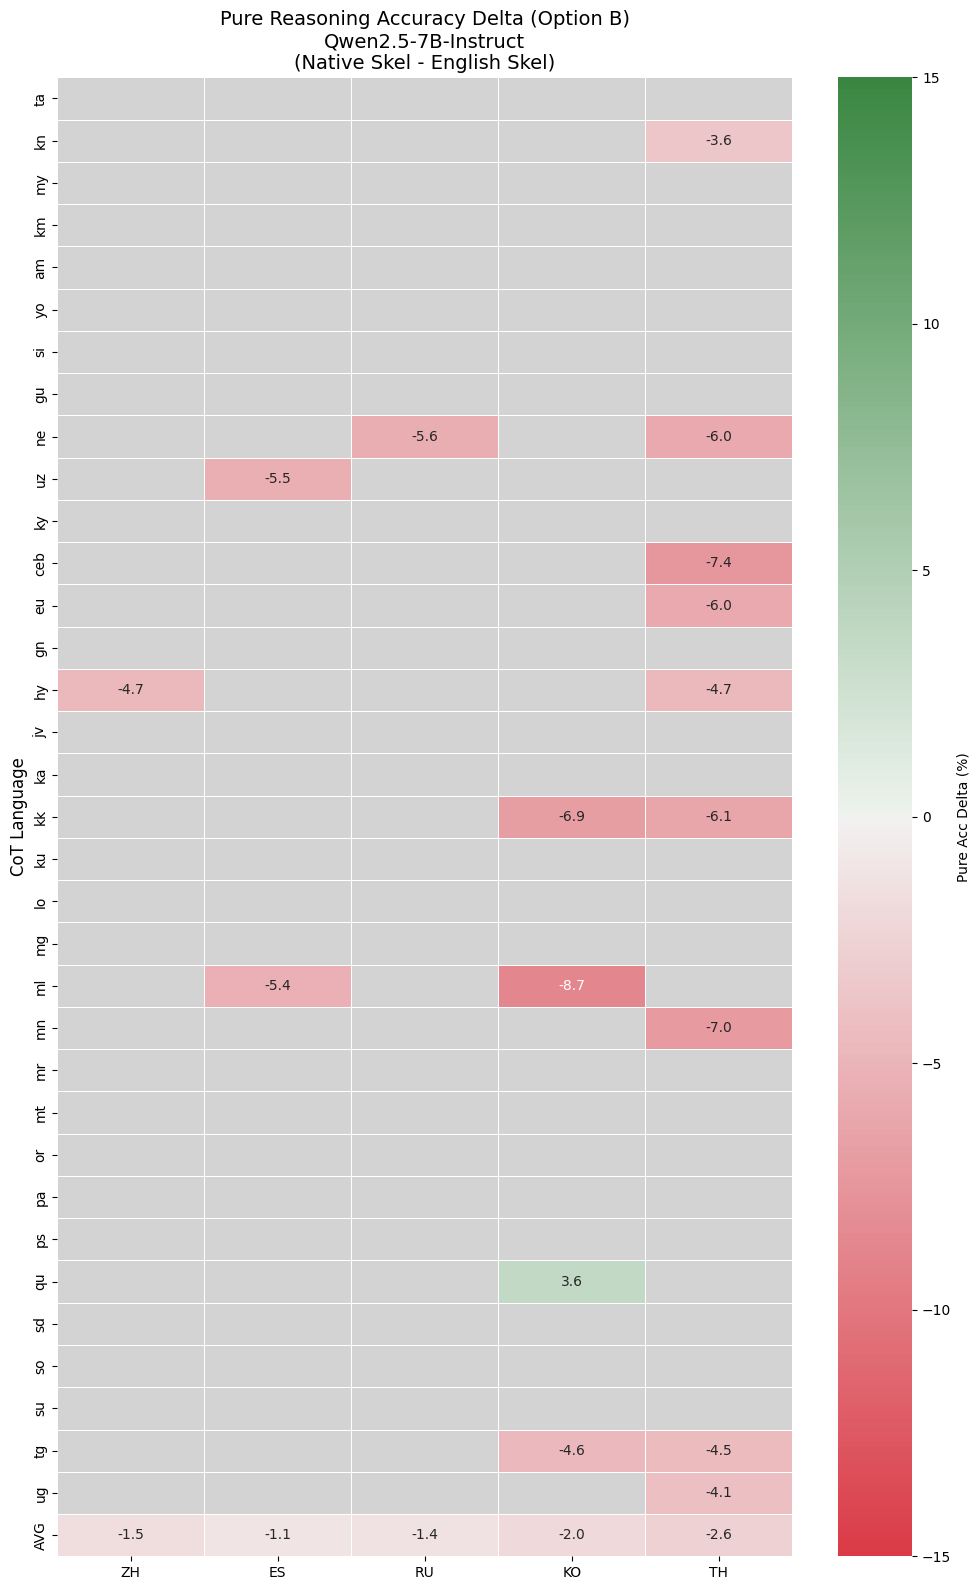

In [5]:
df_pure = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_pure_p = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel in SKELETON_LANGUAGES:
    for cot in COT_LANGUAGES:
        if skel in matrix_pure and cot in matrix_pure[skel]:
            df_pure.loc[cot, skel] = matrix_pure[skel][cot]
            df_pure_p.loc[cot, skel] = pvalue_pure[skel][cot]

df_pure.loc["AVG"] = df_pure.mean(axis=0, skipna=True)
df_pure_p.loc["AVG"] = 0.0

plt.figure(figsize=(10, 16))
ax = sns.heatmap(
    df_pure.astype(float),
    mask=(df_pure_p >= 0.05),
    annot=True, fmt=".1f", cmap=cmap, center=0, vmin=-15, vmax=15, linewidths=0.5,
    xticklabels=x_labels, yticklabels=y_labels, cbar_kws={'label': 'Pure Acc Delta (%)'}
)
ax.set_facecolor('lightgrey')
plt.title(f"Pure Reasoning Accuracy Delta (Option B)\n{MODEL}\n(Native Skel - English Skel)", fontsize=14)
plt.ylabel("CoT Language", fontsize=12)
plt.tight_layout()
plt.show()

## 히트맵 3. Language Compliance Rate Delta
**의미:** 영어 Skeleton 대비 타겟 언어 Skeleton을 사용했을 때, 지시받은 타겟 언어로 잘 답변하는 비율(Language Compliance)이 어떻게 변했는지 보여줍니다.

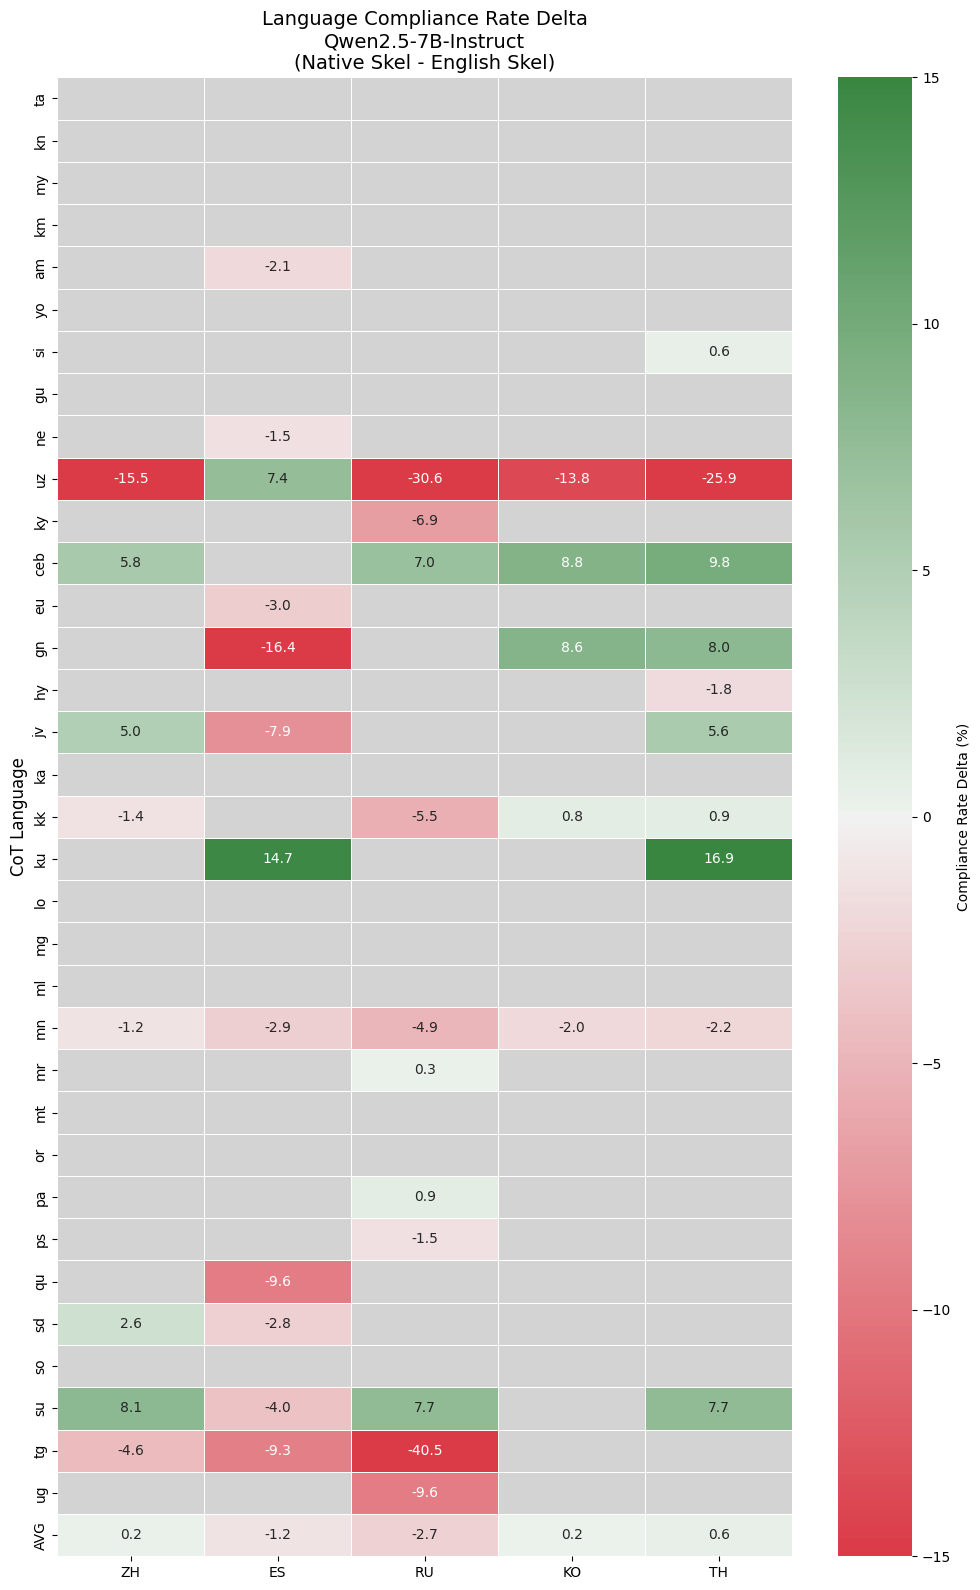

In [6]:
df_comp = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_comp_p = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel in SKELETON_LANGUAGES:
    for cot in COT_LANGUAGES:
        if skel in matrix_comp and cot in matrix_comp[skel]:
            df_comp.loc[cot, skel] = matrix_comp[skel][cot]
            df_comp_p.loc[cot, skel] = pvalue_comp[skel][cot]

df_comp.loc["AVG"] = df_comp.mean(axis=0, skipna=True)
df_comp_p.loc["AVG"] = 0.0

plt.figure(figsize=(10, 16))
ax = sns.heatmap(
    df_comp.astype(float),
    mask=(df_comp_p >= 0.05),
    annot=True, fmt=".1f", cmap=cmap, center=0, vmin=-15, vmax=15, linewidths=0.5,
    xticklabels=x_labels, yticklabels=y_labels, cbar_kws={'label': 'Compliance Rate Delta (%)'}
)
ax.set_facecolor('lightgrey')
plt.title(f"Language Compliance Rate Delta\n{MODEL}\n(Native Skel - English Skel)", fontsize=14)
plt.ylabel("CoT Language", fontsize=12)
plt.tight_layout()
plt.show()